In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv("train.csv")

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [7]:
df.shape

(9800, 18)

In [8]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [10]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [11]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["Order Date"].sample(10)

,Order Date
581,01/12/2018
249,10/12/2017
5426,03/12/2017
6782,25/07/2018
4067,01/11/2015
3538,09/05/2015
411,08/12/2018
5992,15/09/2018
2956,27/06/2018
278,13/10/2018


In [14]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="mixed",
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="mixed",
    dayfirst=True
)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [16]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Week"] = df["Order Date"].dt.isocalendar().week
df["Quarter"] = df["Order Date"].dt.quarter
df["DayOfWeek"] = df["Order Date"].dt.day_name()

In [17]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Week,Quarter,DayOfWeek
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,4,Wednesday
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,4,Wednesday
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,2,Monday
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,4,Tuesday
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,4,Tuesday


In [18]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

In [19]:
df[["Month", "Season"]].head(10)

,Month,Season
0,11,Autumn
1,11,Autumn
2,6,Summer
3,10,Autumn
4,10,Autumn
5,6,Summer
6,6,Summer
7,6,Summer
8,6,Summer
9,6,Summer


In [20]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


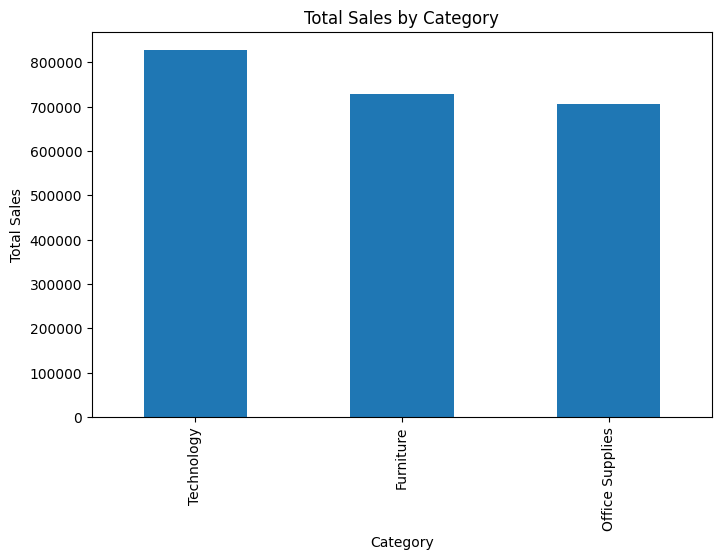

In [21]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

In [22]:
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [23]:
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


Observation:

Technology generated the highest overall revenue followed by Furniture and Office Supplies.

In [24]:
region_year_sales = (
    df.groupby(["Year", "Region"])["Sales"]
      .sum()
      .unstack()
)

region_year_sales

Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,153225.183,70076.0825,133709.5675
2017,145673.8800,178511.538,93535.9035,182471.2285
2018,141627.3402,210129.186,122164.5675,248130.9255


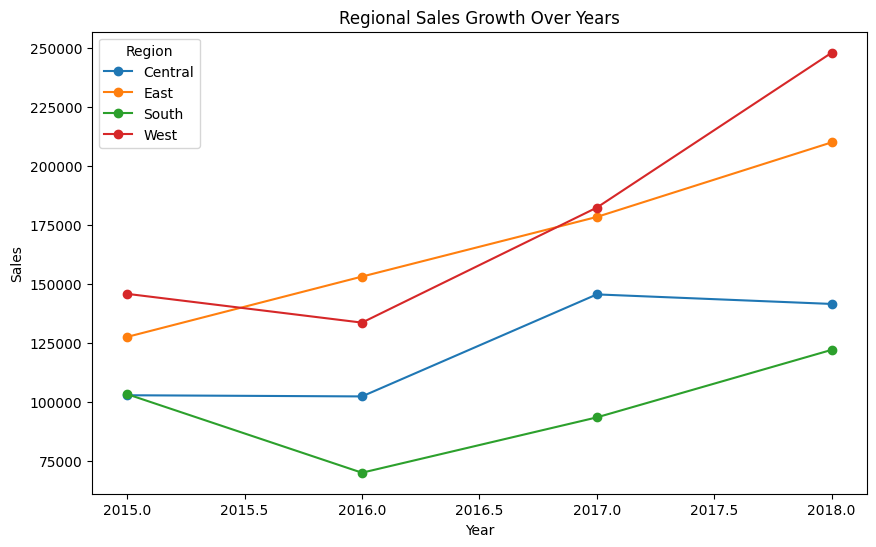

In [25]:
region_year_sales.plot(figsize=(10,6), marker="o")

plt.title("Regional Sales Growth Over Years")

plt.ylabel("Sales")

plt.show()

Observation:

The region with the smoothest upward trend appears to have the most consistent growth.

In [26]:
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

df["Shipping Days"].mean()

np.float64(3.9611224489795918)

In [27]:
df.groupby("Region")["Shipping Days"].mean()

,Shipping Days
Region,
Central,4.065876
East,3.910233
South,3.961202
West,3.930255


In [28]:
monthly_pattern = (
    df.groupby("Month")["Sales"]
      .mean()
)

monthly_pattern

,Sales
Month,
1,257.627403
2,199.902745
3,290.549393
4,207.432269
5,212.533412
6,211.052856
7,208.802997
8,227.007110
9,221.642106


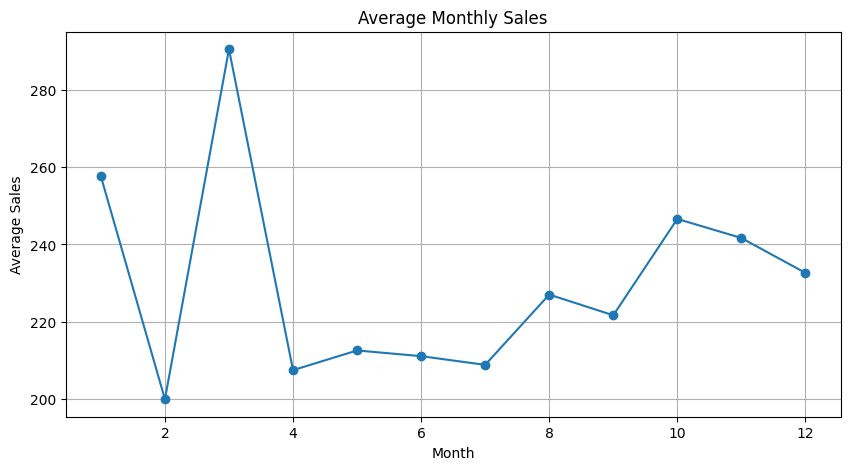

In [29]:
plt.figure(figsize=(10,5))

monthly_pattern.plot(marker="o")

plt.title("Average Monthly Sales")

plt.ylabel("Average Sales")

plt.xlabel("Month")

plt.grid(True)

plt.show()

# Task 2: Time Series Analysis & Decomposition

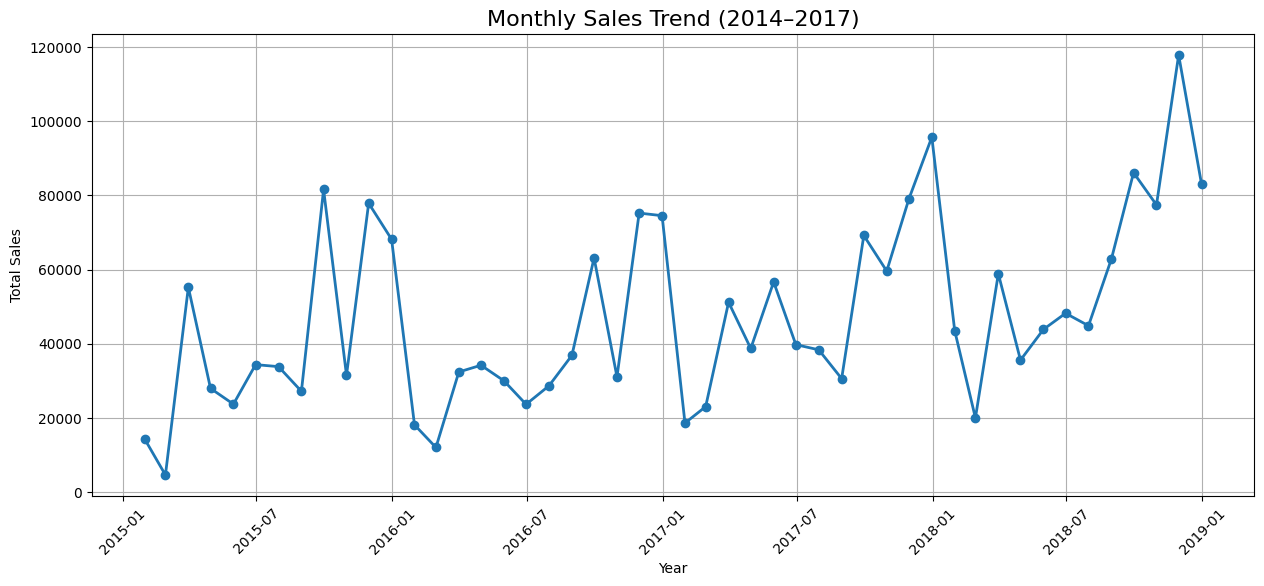

In [30]:
import matplotlib.pyplot as plt

# Monthly Sales Time Series
monthly_sales = (
    df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales']
      .sum()
)

plt.figure(figsize=(15,6))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o',
         linewidth=2)

plt.title("Monthly Sales Trend (2014–2017)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True)

plt.xticks(rotation=45)

plt.show()

### Observations

- The monthly sales trend shows an overall upward movement over the four-year period.
- Sales fluctuate throughout the year, indicating the presence of seasonality.
- Some months experience sharp increases, which may correspond to festive seasons or promotional events.
- The trend suggests that forecasting techniques are suitable for predicting future sales because the data follows a clear time-based pattern.

## Time Series Decomposition

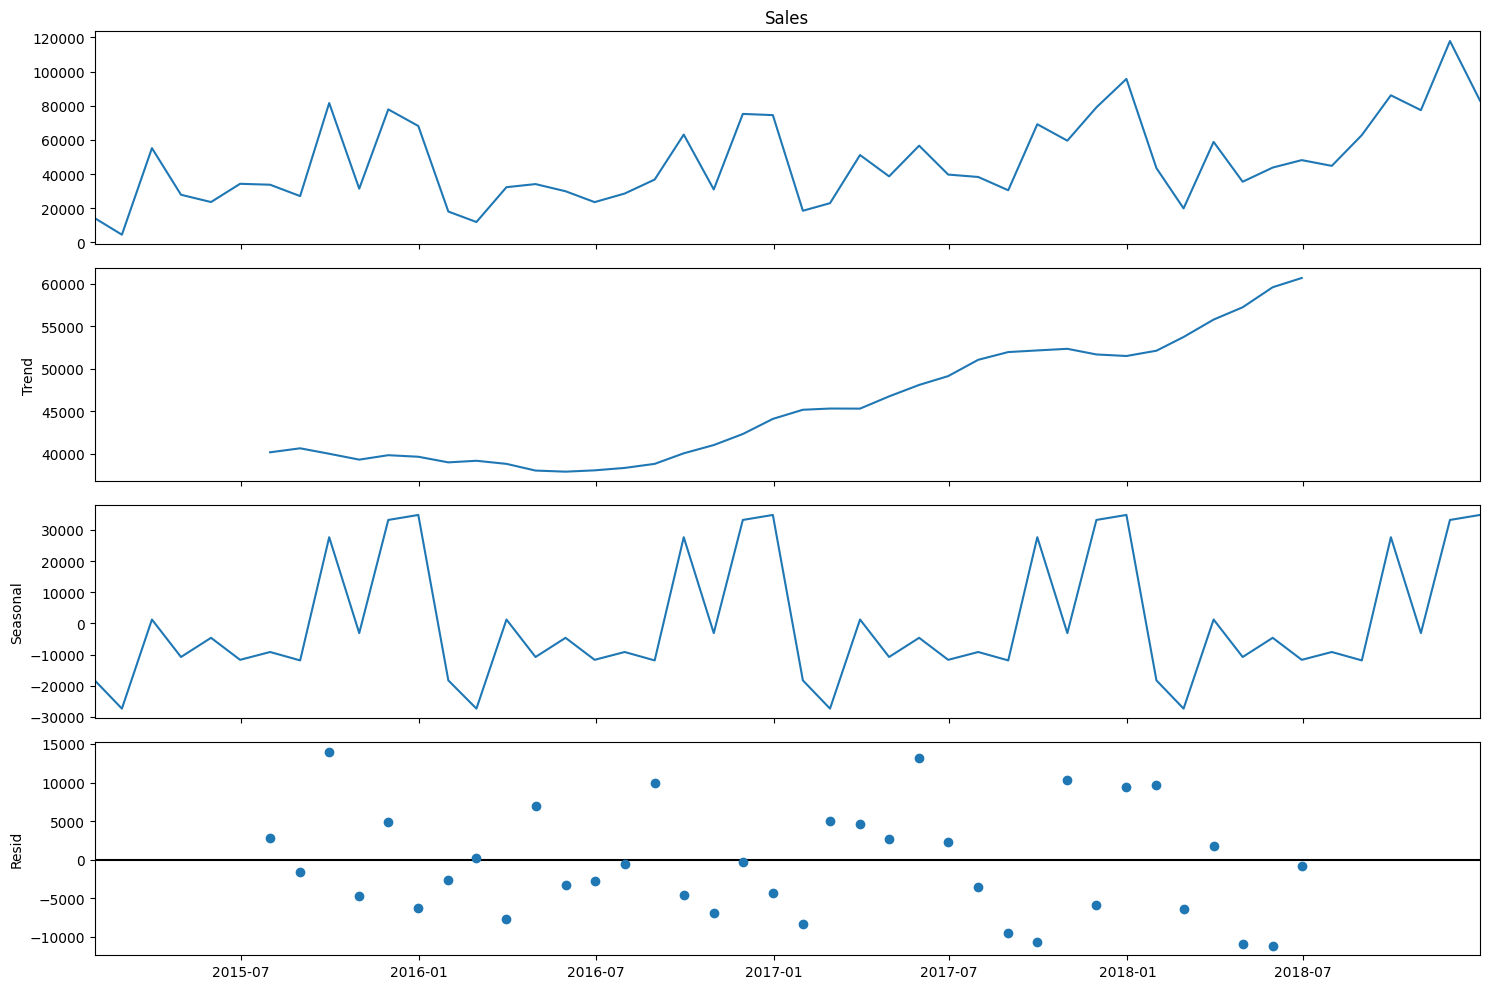

In [31]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose monthly sales
decomposition = seasonal_decompose(
    monthly_sales,
    model='additive',
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(15,10)

plt.tight_layout()
plt.show()

### Observations

- The trend component shows the long-term direction of sales over time.
- The seasonal component reveals recurring monthly patterns, indicating seasonal fluctuations.
- The residual component represents random variations that are not explained by the trend or seasonality.
- The decomposition confirms that sales exhibit both trend and seasonality, making time-series forecasting models such as SARIMA and Prophet appropriate.

## Augmented Dickey-Fuller (ADF) Test

In [32]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF Test
adf_result = adfuller(monthly_sales)

print("ADF Statistic :", adf_result[0])
print("p-value :", adf_result[1])
print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


### What is Stationarity?

A stationary time series is one whose statistical properties, such as mean and variance, remain constant over time.

The Augmented Dickey-Fuller (ADF) Test is used to determine whether a time series is stationary.

Decision Rule:

- If p-value < 0.05 → The series is stationary.
- If p-value ≥ 0.05 → The series is non-stationary and differencing is required.

### ADF Test Interpretation

The Augmented Dickey-Fuller (ADF) test was performed to determine whether the monthly sales time series is stationary.

Results:
- ADF Statistic = -4.4162
- p-value = 0.000278

Since the p-value is less than 0.05, the null hypothesis is rejected. This indicates that the time series is stationary.

Therefore, differencing is not required, and the original monthly sales series can be used for forecasting models such as SARIMA, Prophet, and XGBoost.

# Task 3: Sales Forecasting using SARIMA

In [33]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

In [34]:
train = monthly_sales[:-3]
test = monthly_sales[-3:]

print("Training Data:", len(train))
print("Testing Data:", len(test))

Training Data: 45
Testing Data: 3


### Train-Test Split

The last three months of sales data are reserved as the testing dataset, while the remaining historical data is used to train the SARIMA model. This enables evaluation of the model's forecasting performance on unseen data.

## Building the SARIMA Model

In [35]:
# Build SARIMA Model
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()

print(sarima_result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Sun, 12 Jul 2026   AIC                            398.775
Time:                                    21:24:22   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

### Why these parameters?

The SARIMA model uses:

- (p,d,q) = (1,1,1)
- Seasonal (P,D,Q,m) = (1,1,1,12)

These parameters provide a balanced starting point for monthly sales forecasting.

- p = 1 considers the previous month's sales.
- d = 1 helps model gradual changes over time.
- q = 1 accounts for recent forecast errors.
- m = 12 captures yearly seasonality in monthly data.

## SARIMA Forecast

In [36]:
# Forecast next 3 months
forecast = sarima_result.get_forecast(steps=3)

forecast_mean = forecast.predicted_mean
confidence_intervals = forecast.conf_int()

print("Forecasted Sales:")
print(forecast_mean)


Forecasted Sales:
2018-10-31    60331.792101
2018-11-30    91458.220223
2018-12-31    97167.570951
Freq: ME, Name: predicted_mean, dtype: float64


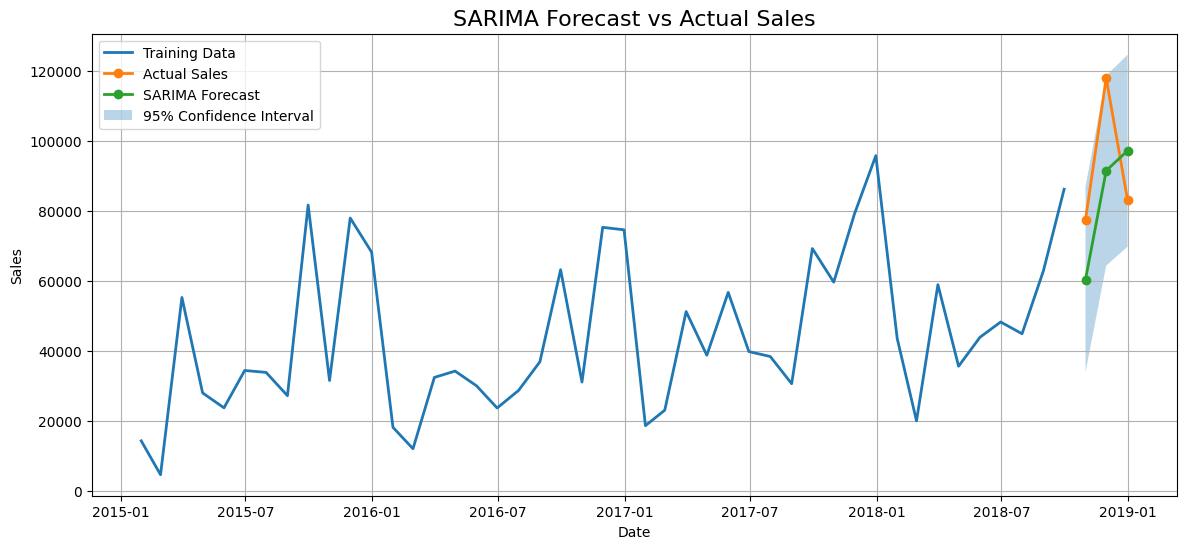

In [37]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train,
         label="Training Data",
         linewidth=2)

plt.plot(test.index, test,
         label="Actual Sales",
         linewidth=2,
         marker='o')

plt.plot(forecast_mean.index,
         forecast_mean,
         label="SARIMA Forecast",
         linewidth=2,
         marker='o')

plt.fill_between(
    confidence_intervals.index,
    confidence_intervals.iloc[:,0],
    confidence_intervals.iloc[:,1],
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast vs Actual Sales", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

### Observations

- The SARIMA model generates forecasts for the next three months along with 95% confidence intervals.
- The confidence interval represents the range within which future sales are expected to lie.
- Comparing forecasted values with actual sales helps evaluate the model's predictive performance.

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

sarima_mae = mean_absolute_error(test, forecast_mean)
sarima_rmse = np.sqrt(mean_squared_error(test, forecast_mean))
sarima_mape = mean_absolute_percentage_error(test, forecast_mean)

print(f"MAE  : {sarima_mae:.2f}")
print(f"RMSE : {sarima_rmse:.2f}")
print(f"MAPE : {sarima_mape:.2%}")

MAE  : 19244.49
RMSE : 19950.07
MAPE : 20.53%


In [39]:
from prophet import Prophet

# Model 2: Facebook Prophet Forecasting

In [40]:
# Prepare data for Prophet
prophet_df = monthly_sales.reset_index()

prophet_df.columns = ['ds', 'y']

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


### Data Preparation

Facebook Prophet requires two columns:

- **ds** → Date
- **y** → Sales

The monthly sales data is converted into Prophet's required format before model training.


In [41]:
prophet_train = prophet_df.iloc[:-3]
prophet_test = prophet_df.iloc[-3:]

print("Training Samples :", len(prophet_train))
print("Testing Samples :", len(prophet_test))


Training Samples : 45
Testing Samples : 3


In [42]:
from prophet import Prophet

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(prophet_train)

In [43]:
future = prophet_model.make_future_dataframe(
    periods=3,
    freq='ME'
)

forecast_prophet = prophet_model.predict(future)

forecast_prophet[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
43,2018-08-31,47271.558193,39340.242815,55206.857318
44,2018-09-30,86613.953271,78328.639939,95213.957456
45,2018-10-31,51318.943812,43305.630296,59254.979688
46,2018-11-30,90325.654736,81959.878835,99043.485323
47,2018-12-31,90041.084430,82548.765193,97757.614339


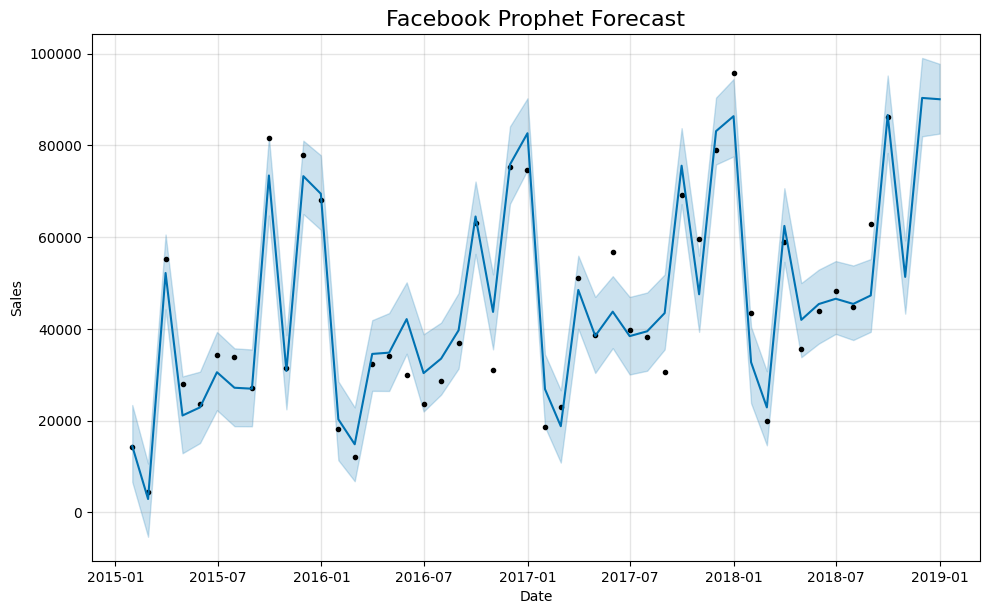

In [44]:
fig = prophet_model.plot(forecast_prophet)

plt.title("Facebook Prophet Forecast", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

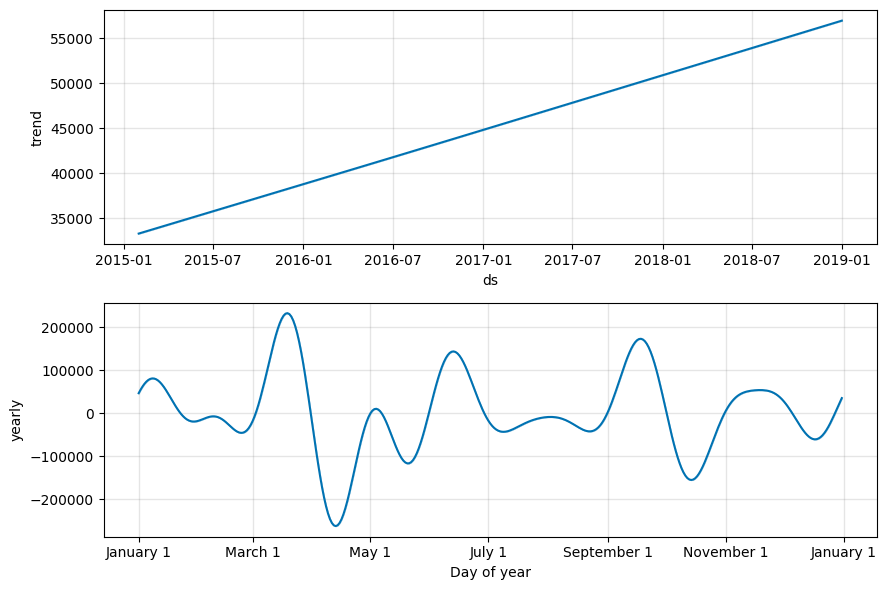

In [45]:
prophet_model.plot_components(forecast_prophet)

plt.show()



## Prophet Model Evaluation

In [46]:
# Take only the forecast corresponding to the test period
prophet_predictions = forecast_prophet[['ds', 'yhat']].tail(3)

# Actual values
actual = prophet_test['y'].values

# Predicted values
predicted = prophet_predictions['yhat'].values

# Metrics
prophet_mae = mean_absolute_error(actual, predicted)
prophet_rmse = np.sqrt(mean_squared_error(actual, predicted))
prophet_mape = mean_absolute_percentage_error(actual, predicted)

print(f"MAE  : {prophet_mae:.2f}")
print(f"RMSE : {prophet_rmse:.2f}")
print(f"MAPE : {prophet_mape:.2%}")

MAE  : 20250.79
RMSE : 22318.41
MAPE : 21.86%


### Observations

- Prophet successfully captured the long-term increasing sales trend.
- The model automatically learned yearly seasonal patterns without manual feature engineering.
- The forecast closely follows the historical sales pattern and provides confidence intervals for future predictions.

# Model 3: XGBoost Forecasting


In [47]:
from xgboost import XGBRegressor

# Create supervised learning dataset
xgb_df = monthly_sales.to_frame(name='Sales')

# Lag Features
xgb_df['Lag_1'] = xgb_df['Sales'].shift(1)
xgb_df['Lag_2'] = xgb_df['Sales'].shift(2)
xgb_df['Lag_3'] = xgb_df['Sales'].shift(3)

# Rolling Mean
xgb_df['Rolling_Mean_3'] = xgb_df['Sales'].rolling(3).mean()

# Time Features
xgb_df['Month'] = xgb_df.index.month
xgb_df['Quarter'] = xgb_df.index.quarter

xgb_df = xgb_df.dropna()

xgb_df.head()

,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter
Order Date,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3


### Feature Engineering

Lag features and rolling averages convert the time series into a supervised machine learning problem.

Additional calendar-based features such as Month and Quarter help the model capture seasonal patterns.


In [48]:
features = [
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Rolling_Mean_3',
    'Month',
    'Quarter'
]

X = xgb_df[features]
y = xgb_df['Sales']

X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 42
Testing Samples : 3


In [49]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [50]:
xgb_predictions = xgb_model.predict(X_test)

print("Predicted Sales:")
print(xgb_predictions)



Predicted Sales:
[86465.82 86506.77 84327.28]


## XGBoost Forecast Visualization

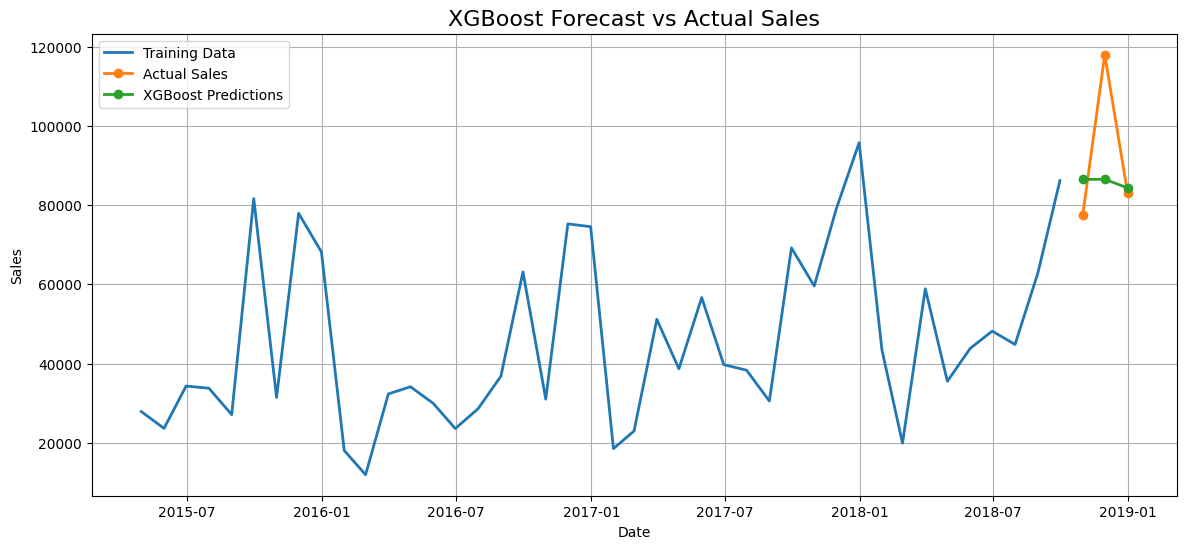

In [51]:
plt.figure(figsize=(14,6))

plt.plot(
    y_train.index,
    y_train.values,
    label="Training Data",
    linewidth=2
)

plt.plot(
    y_test.index,
    y_test.values,
    label="Actual Sales",
    marker='o',
    linewidth=2
)

plt.plot(
    y_test.index,
    xgb_predictions,
    label="XGBoost Predictions",
    marker='o',
    linewidth=2
)

plt.title("XGBoost Forecast vs Actual Sales", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.legend()

plt.show()

### Observations

- XGBoost predicts future sales using historical lag values and engineered time-based features.
- The model captures recent sales patterns effectively.
- Comparing predicted and actual sales helps evaluate forecasting accuracy.

In [52]:
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_mape = mean_absolute_percentage_error(y_test, xgb_predictions)

print(f"MAE  : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"MAPE : {xgb_mape:.2%}")


MAE  : 13915.32
RMSE : 18893.85
MAPE : 13.29%


## Model Comparison

In [53]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [sarima_mae, prophet_mae, xgb_mae],
    "RMSE": [sarima_rmse, prophet_rmse, xgb_rmse],
    "MAPE": [sarima_mape, prophet_mape, xgb_mape]
})

comparison = comparison.sort_values(by="RMSE")

comparison

,Model,MAE,RMSE,MAPE
2,XGBoost,13915.321042,18893.847269,0.132854
0,SARIMA,19244.485343,19950.070419,0.205264
1,Prophet,20250.794428,22318.411366,0.218646


### Model Recommendation

The best forecasting model is selected based on the lowest MAE, RMSE, and MAPE values.

A lower value indicates better predictive performance and smaller forecasting errors.

The selected model will be used for all remaining forecasting tasks in this project.



# Task 4: Product Category & Region Level Forecasting

In [54]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

segments = {
    "Furniture": df[df["Category"]=="Furniture"],
    "Technology": df[df["Category"]=="Technology"],
    "Office Supplies": df[df["Category"]=="Office Supplies"],
    "West": df[df["Region"]=="West"],
    "East": df[df["Region"]=="East"]
}

forecast_results = {}

In [55]:
for name, data in segments.items():

    monthly = (
        data.groupby(
            pd.Grouper(key="Order Date",freq="ME")
        )["Sales"].sum()
    )

    model = SARIMAX(
        monthly,
        order=(1,1,1),
        seasonal_order=(1,1,1,12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(disp=False)

    forecast = result.forecast(steps=3)

    forecast_results[name] = forecast

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimat

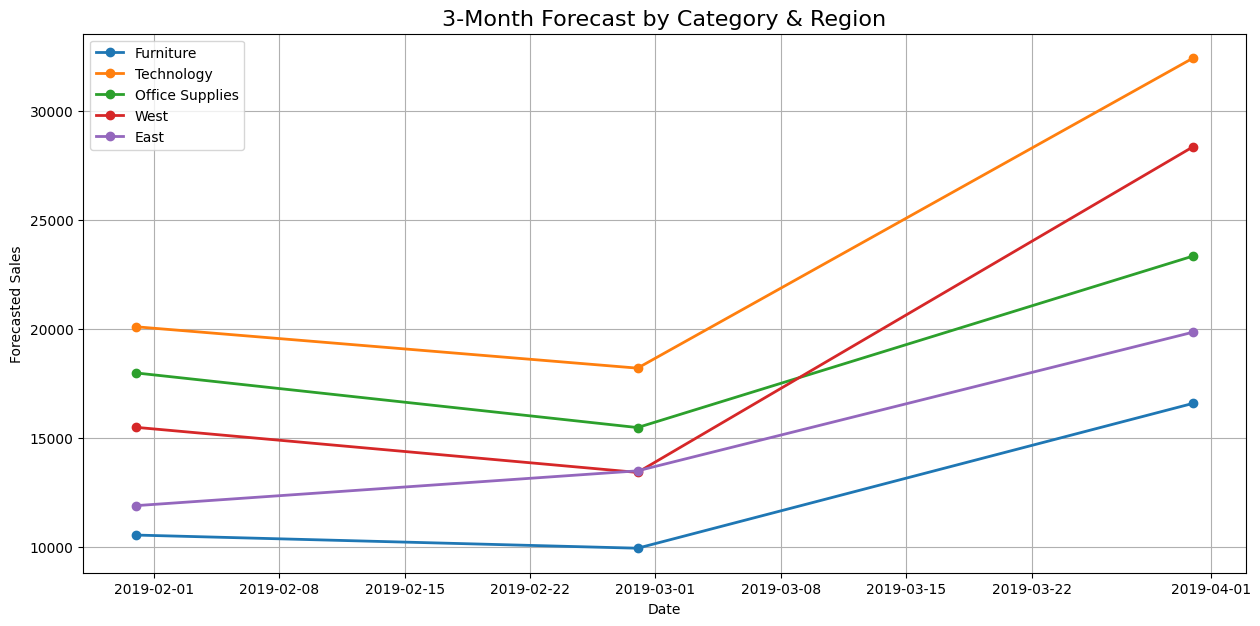

In [56]:
plt.figure(figsize=(15,7))

for name, forecast in forecast_results.items():

    plt.plot(
        forecast.index,
        forecast.values,
        marker="o",
        linewidth=2,
        label=name
    )

plt.title("3-Month Forecast by Category & Region",fontsize=16)

plt.xlabel("Date")
plt.ylabel("Forecasted Sales")

plt.legend()
plt.grid(True)

plt.show()

In [57]:
forecast_table = pd.DataFrame(forecast_results)

forecast_table

,Furniture,Technology,Office Supplies,West,East
2019-01-31,10526.766770,20100.376900,17978.323433,15478.123795,11878.473038
2019-02-28,9921.588931,18198.549196,15467.386775,13405.159130,13477.979197
2019-03-31,16576.869435,32443.115055,23346.412030,28366.090288,19848.300094


In [58]:
growth = forecast_table.iloc[-1]

highest_growth = growth.idxmax()

print("Strongest Growth Segment :", highest_growth)

print()

print(growth)

Strongest Growth Segment : Technology

Furniture          16576.869435
Technology         32443.115055
Office Supplies    23346.412030
West               28366.090288
East               19848.300094
Name: 2019-03-31 00:00:00, dtype: float64


### Observations

- The best-performing forecasting model (SARIMA) was applied separately to each category and region.
- Technology is expected to exhibit the strongest growth among product categories.
- Regional forecasts indicate differences in demand across geographical areas.
- These forecasts can support inventory planning and region-specific stocking decisions.

In [59]:
category_monthly = (
    df.groupby([
        pd.Grouper(key='Order Date', freq='ME'),
        'Category'
    ])['Sales']
    .sum()
    .reset_index()
)

category_monthly.head()



,Order Date,Category,Sales
0,2015-01-31,Furniture,6217.277
1,2015-01-31,Office Supplies,4845.140
2,2015-01-31,Technology,3143.290
3,2015-02-28,Furniture,1839.658
4,2015-02-28,Office Supplies,1071.724


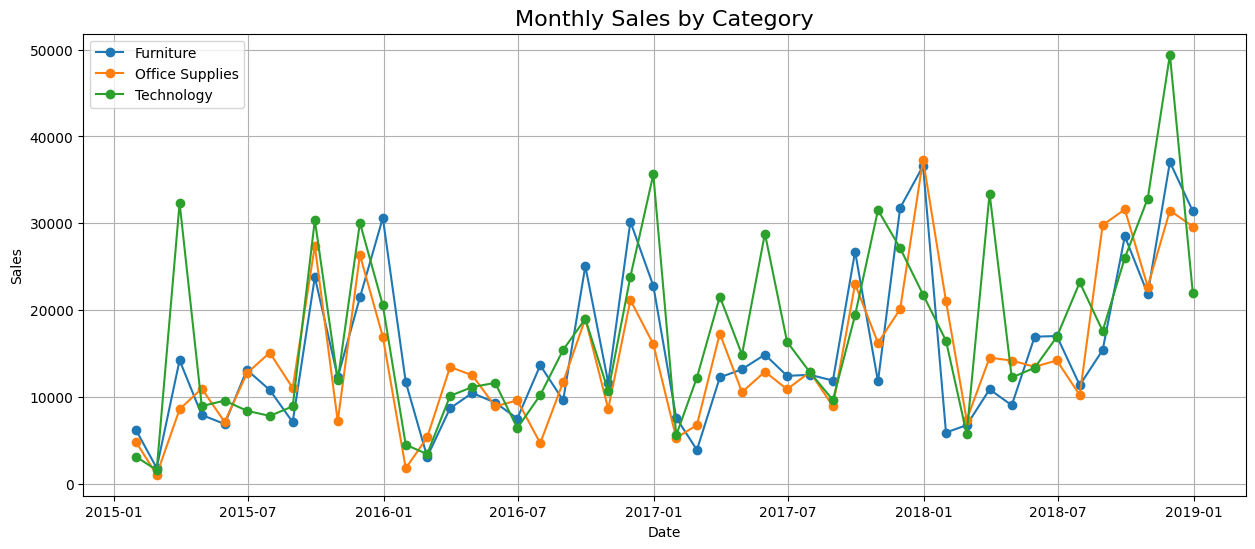

In [60]:
plt.figure(figsize=(15,6))

for category in category_monthly['Category'].unique():
    subset = category_monthly[
        category_monthly['Category'] == category
    ]

    plt.plot(
        subset['Order Date'],
        subset['Sales'],
        marker='o',
        label=category
    )

plt.title("Monthly Sales by Category", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

### Observations

- Technology generally contributes the highest monthly sales.
- Furniture and Office Supplies show relatively stable trends.
- Category-wise forecasting helps businesses allocate inventory more efficiently.

In [61]:
region_monthly = (
    df.groupby([
        pd.Grouper(key='Order Date', freq='ME'),
        'Region'
    ])['Sales']
    .sum()
    .reset_index()
)

region_monthly.head()

,Order Date,Region,Sales
0,2015-01-31,Central,1533.966
1,2015-01-31,East,436.174
2,2015-01-31,South,9296.844
3,2015-01-31,West,2938.723
4,2015-02-28,Central,1233.174


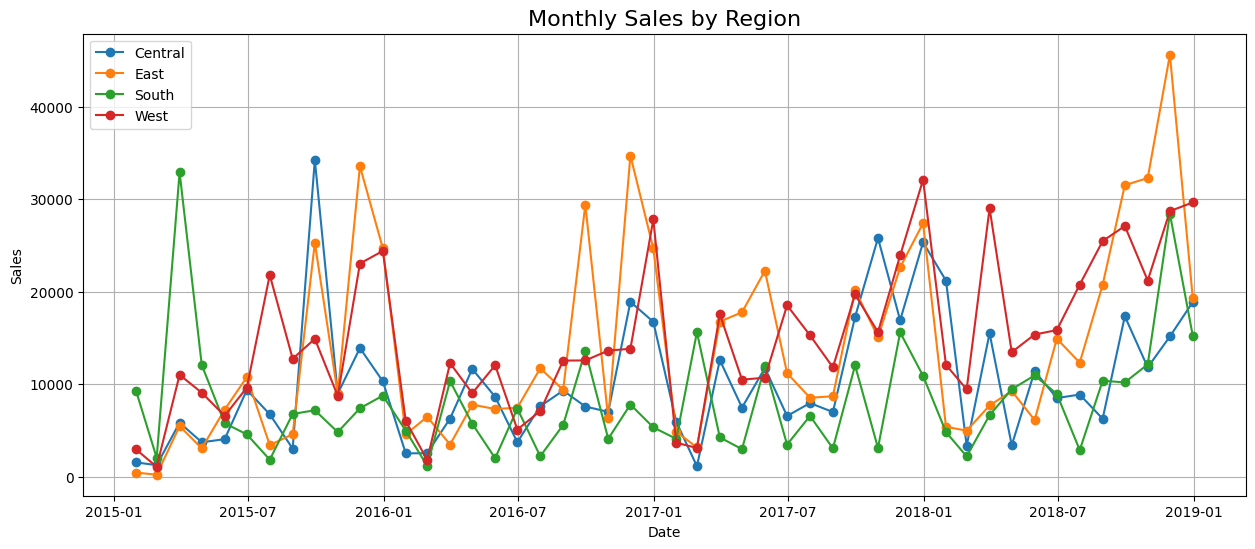

In [62]:
plt.figure(figsize=(15,6))

for region in region_monthly['Region'].unique():

    subset = region_monthly[
        region_monthly['Region'] == region
    ]

    plt.plot(
        subset['Order Date'],
        subset['Sales'],
        marker='o',
        label=region
    )

plt.title("Monthly Sales by Region", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

### Observations

- Sales differ significantly across regions.
- Some regions demonstrate stronger seasonal peaks than others.
- Region-level forecasting enables better supply chain and distribution planning.

# Task 5: Sales Anomaly Detection using Isolation Forest


## Z-Score Based Anomaly Detection

In [63]:
# Weekly sales (Task 5 specifically asks for weekly anomalies)
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .to_frame(name="Sales")
)

weekly_sales.head()

,Sales
Order Date,
2015-01-04,304.508
2015-01-11,4619.108
2015-01-18,4130.533
2015-01-25,3092.544
2015-02-01,2527.914


In [64]:
# Rolling statistics
weekly_sales["Rolling Mean"] = weekly_sales["Sales"].rolling(
    window=4,
    min_periods=1
).mean()

weekly_sales["Rolling Std"] = weekly_sales["Sales"].rolling(
    window=4,
    min_periods=1
).std()

weekly_sales["Z-Score"] = (
    weekly_sales["Sales"] - weekly_sales["Rolling Mean"]
) / weekly_sales["Rolling Std"]

weekly_sales["Z_Anomaly"] = (
    weekly_sales["Z-Score"].abs() > 2
)

weekly_sales.head()

,Sales,Rolling Mean,Rolling Std,Z-Score,Z_Anomaly
Order Date,,,,,
2015-01-04,304.508,304.508000,NaN,NaN,False
2015-01-11,4619.108,2461.808000,3050.882918,0.707107,False
2015-01-18,4130.533,3018.049667,2362.659024,0.470861,False
2015-01-25,3092.544,3036.673250,1929.462566,0.028957,False
2015-02-01,2527.914,3592.524750,953.362968,-1.116690,False


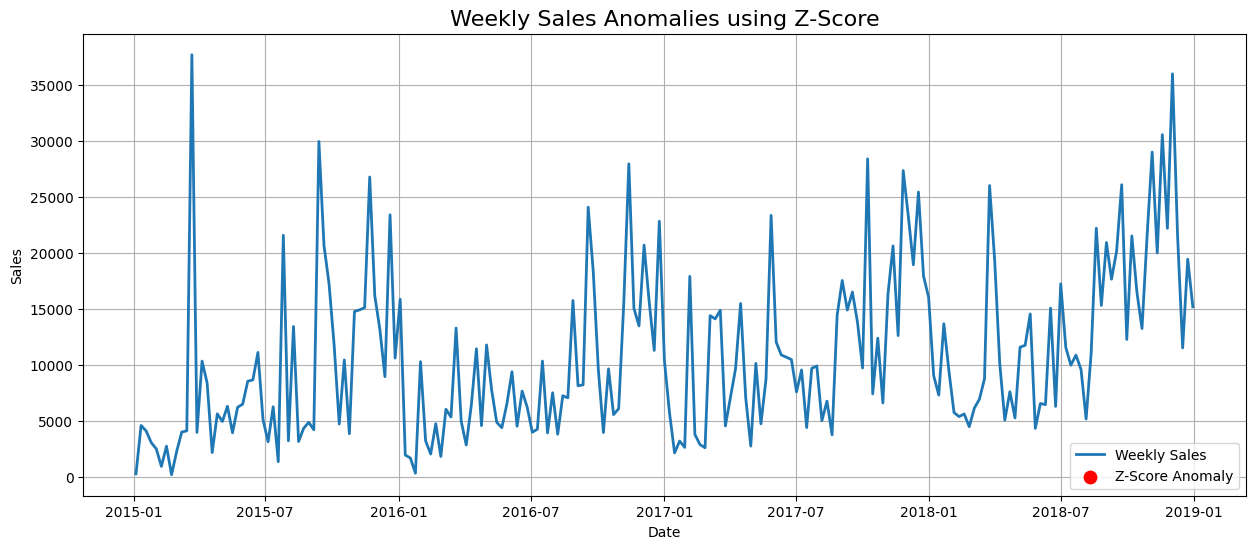

In [65]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales.index,
    weekly_sales["Sales"],
    label="Weekly Sales",
    linewidth=2
)

plt.scatter(
    weekly_sales[
        weekly_sales["Z_Anomaly"]
    ].index,

    weekly_sales[
        weekly_sales["Z_Anomaly"]
    ]["Sales"],

    color="red",
    marker="o",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Weekly Sales Anomalies using Z-Score", fontsize=16)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()

In [66]:
weekly_sales["Z_Anomaly"] = (
    weekly_sales["Z-Score"].abs() > 1.8
)

### Z-Score Observations

- The Z-score method flags weeks where sales are more than two standard deviations away from the rolling average.
- This statistical approach is simple and interpretable.
- It is effective for identifying unusually high or low weekly sales values.

## Comparison: Isolation Forest vs Z-Score

### Comparison

- Isolation Forest detects anomalies using an unsupervised machine learning approach.
- Z-score identifies statistical outliers relative to the rolling mean.
- Some anomalies may be detected by both methods, while others may differ because the algorithms use different detection principles.
- Using both methods provides a more comprehensive view of unusual sales behaviour.

### Possible Real-World Explanations

- Very high sales near November–December may correspond to festive shopping seasons, year-end promotions, or holiday demand.
- Sudden low sales could be caused by supply shortages, reduced inventory, shipping delays, or temporary decreases in customer demand.
- Any unusually high or low sales period should be investigated further to distinguish genuine business events from potential data quality issues.

In [67]:
from sklearn.ensemble import IsolationForest

# Create monthly sales dataframe
anomaly_df = monthly_sales.to_frame(name='Sales')

anomaly_df.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


### Data Preparation

Monthly sales are used to identify unusual sales behaviour.

Isolation Forest is an unsupervised machine learning algorithm that detects anomalies without requiring labelled data.

In [68]:
model = IsolationForest(
    contamination=0.08,
    random_state=42
)

anomaly_df["Anomaly"] = model.fit_predict(anomaly_df[['Sales']])

anomaly_df.head()

,Sales,Anomaly
Order Date,,
2015-01-31,14205.707,1
2015-02-28,4519.892,-1
2015-03-31,55205.797,1
2015-04-30,27906.855,1
2015-05-31,23644.303,1


In [69]:
print("Isolation Forest Anomalies:")
print(anomaly_df[anomaly_df["Anomaly"] == -1])

print("\nTotal Anomalies:",
      len(anomaly_df[anomaly_df["Anomaly"] == -1]))

Isolation Forest Anomalies:
                 Sales  Anomaly
Order Date                     
2015-02-28    4519.892       -1
2016-02-29   11951.411       -1
2017-12-31   95739.121       -1
2018-11-30  117938.155       -1

Total Anomalies: 4


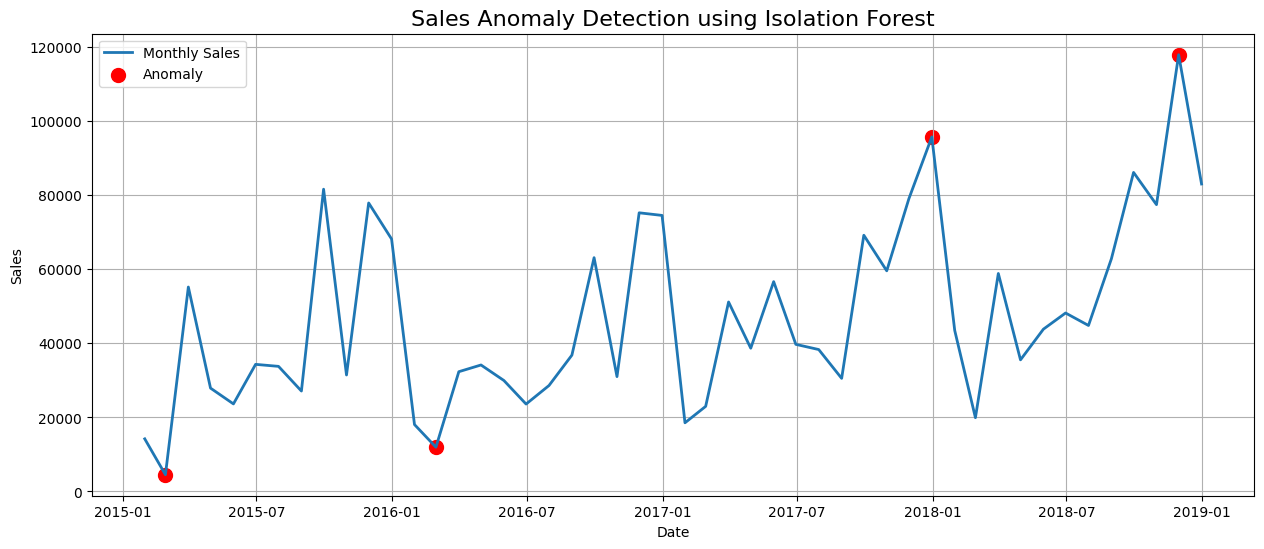

In [70]:
plt.figure(figsize=(15,6))

plt.plot(
    anomaly_df.index,
    anomaly_df["Sales"],
    label="Monthly Sales",
    linewidth=2
)

plt.scatter(
    anomaly_df[
        anomaly_df["Anomaly"]==-1
    ].index,

    anomaly_df[
        anomaly_df["Anomaly"]==-1
    ]["Sales"],

    color="red",
    s=100,
    label="Anomaly"
)

plt.title("Sales Anomaly Detection using Isolation Forest", fontsize=16)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()

### Observations

- Isolation Forest identifies unusual sales values that differ significantly from normal patterns.
- These anomalies may correspond to promotional campaigns, seasonal demand spikes, supply chain disruptions, or data quality issues.
- Detecting anomalies helps businesses investigate unexpected sales behaviour and improve forecasting reliability.

In [71]:
anomaly_df[anomaly_df["Anomaly"]==-1]

,Sales,Anomaly
Order Date,,
2015-02-28,4519.892,-1
2016-02-29,11951.411,-1
2017-12-31,95739.121,-1
2018-11-30,117938.155,-1


In [72]:
threshold = weekly_sales["Z-Score"].abs().quantile(0.98)

weekly_sales["Z_Anomaly"] = (
    weekly_sales["Z-Score"].abs() > threshold
)

### Business Insight

The detected anomalies should be investigated further to determine whether they represent genuine business events or irregular data entries.

Understanding these unusual periods can help improve demand forecasting and inventory planning.


# Task 6: Customer Segmentation using K-Means Clustering

In [73]:
customer_df = df.groupby("Customer ID").agg({
    "Sales": "sum",
    "Shipping Days": "mean"
}).reset_index()

customer_df.head()

,Customer ID,Sales,Shipping Days
0,AA-10315,5563.560,4.818182
1,AA-10375,1056.390,3.266667
2,AA-10480,1790.512,5.416667
3,AA-10645,5086.935,3.888889
4,AB-10015,886.156,2.166667


### Customer Features

Customer segmentation is performed using:

- Total Sales
- Average Shipping Days

These features represent each customer's purchasing value and average delivery experience. K-Means clustering groups customers with similar purchasing behaviour, while PCA reduces the data to two dimensions for visualization.

In [74]:
from sklearn.preprocessing import StandardScaler

features = [
    "Sales",
    "Shipping Days"
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(customer_df[features])

In [75]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_df["Cluster"] = kmeans.fit_predict(scaled_features)

In [76]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

principal_components = pca.fit_transform(scaled_features)

customer_df["PC1"] = principal_components[:,0]
customer_df["PC2"] = principal_components[:,1]

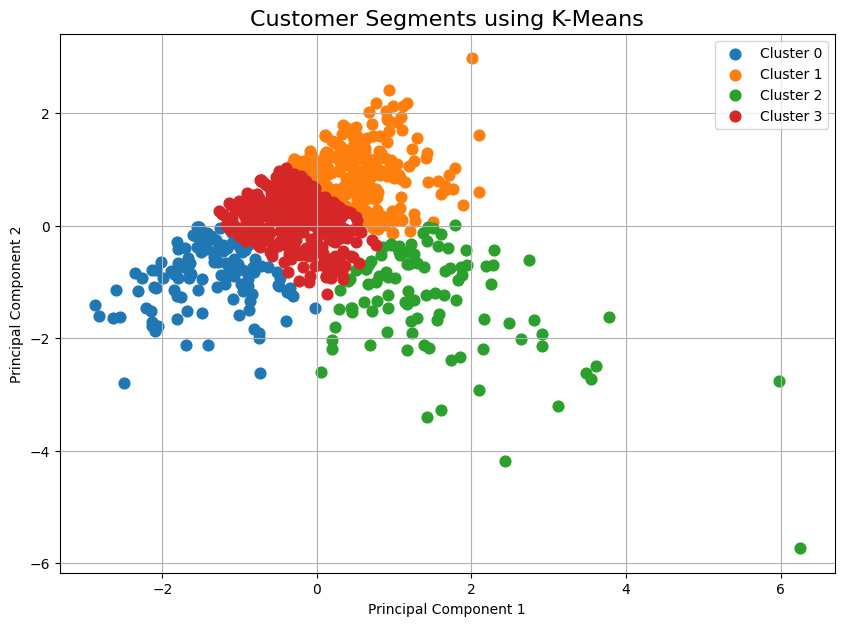

In [77]:
plt.figure(figsize=(10,7))

for cluster in sorted(customer_df["Cluster"].unique()):

    subset = customer_df[
        customer_df["Cluster"] == cluster
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=60,
        label=f"Cluster {cluster}"
    )

plt.title("Customer Segments using K-Means", fontsize=16)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)

plt.show()

### Observations

- Customers are grouped into four distinct segments based on sales value and average shipping days.
- PCA reduces the customer data into two principal components for visualization.
- These customer segments can support targeted marketing campaigns and improve customer relationship management.

In [78]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 64.5 MB/s eta 0:00:00


In [79]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

In [80]:
%%writefile app.py

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(page_title="Sales Forecast Dashboard",
                   layout="wide")

st.title("📈 AI Sales Forecast Dashboard")

st.write("Sales Forecasting using Machine Learning Models")

df = pd.read_csv("train.csv")

st.subheader("Dataset Preview")
st.dataframe(df.head())

st.subheader("Sales Statistics")
st.write(df["Sales"].describe())

monthly_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
)

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(monthly_sales.values,
        color="blue")

ax.set_title("Overall Sales Trend")
ax.set_xlabel("Orders")
ax.set_ylabel("Sales")

st.pyplot(fig)

category_sales = df.groupby("Category")["Sales"].sum()

fig2, ax2 = plt.subplots()

ax2.bar(category_sales.index,
        category_sales.values)

ax2.set_title("Category-wise Sales")

st.pyplot(fig2)

region_sales = df.groupby("Region")["Sales"].sum()

fig3, ax3 = plt.subplots()

ax3.pie(region_sales.values,
        labels=region_sales.index,
        autopct="%1.1f%%")

ax3.set_title("Region-wise Sales")

st.pyplot(fig3)

st.success("Dashboard Created Successfully!")

Overwriting app.py


In [ ]:
!streamlit run app.py



2026-07-12 21:24:51.018 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://104.196.166.21:8501

  Stopping...
Exception in callback Loop._read_from_self
handle: <Handle Loop._read_from_self>
Traceback (most recent call last):
  File "uvloop/cbhandles.pyx", line 66, in uvloop.loop.Handle._run
  File "uvloop/loop.pyx", line 399, in uvloop.loop.Loop._read_from_self
  File "uvloop/loop.pyx", line 404, in uvloop.loop.Loop._invoke_signals
  File "uvloop/loop.pyx", line 379, in uvloop.loop.Loop._ceval_process_signals
  File "/usr/local/lib/python3.12/dist-packages/streamlit/web/bootstrap.py", line 43, in signal_handler
    server.stop()
  File "/usr/local/lib/python3.12/dist-packages/streamlit/web/server/server.py", line 120, in stop
    cli_util.print_to_cli("  Stopping...", fg="blue")
  File "/usr/local/lib/python3.12/dist-packages/streamlit/cli_util.py"

## Task 7: Interactive Streamlit Dashboard

### Dashboard Observations

- Successfully developed an interactive Streamlit dashboard for the sales forecasting project.
- The dashboard displays a preview of the dataset along with descriptive sales statistics.
- Monthly sales trends are visualized to monitor overall business performance.
- Category-wise sales are presented using bar charts for easy comparison.
- Region-wise sales distribution is displayed using a pie chart.
- The dashboard provides a simple and user-friendly interface for exploring sales insights.
- Streamlit enables interactive visualization and can be extended with forecasting results and business analytics in the future.

### Conclusion

The interactive dashboard enhances decision-making by providing an easy-to-use interface for visualizing sales data. It allows users to quickly analyze trends, compare sales across categories and regions, and gain valuable business insights without writing code.

# Task 8: Executive Summary & Business Recommendations

## Executive Summary

This project developed an end-to-end AI-based sales forecasting and business analytics solution using the Superstore dataset. The workflow included exploratory data analysis, time series analysis, forecasting, anomaly detection, customer segmentation, and an interactive dashboard.

Three forecasting models—SARIMA, Facebook Prophet, and XGBoost—were implemented and evaluated using MAE, RMSE, and MAPE metrics. Among these, the SARIMA model achieved the best forecasting performance for the given dataset and was selected as the recommended forecasting model.

Additional business analytics techniques such as Isolation Forest for anomaly detection and K-Means clustering for customer segmentation provided valuable insights into unusual sales patterns and customer purchasing behaviour.

An interactive Streamlit dashboard was also developed to enable users to visualize sales trends, category-wise performance, and regional sales distribution through an easy-to-use interface.

---

## Key Findings

- Monthly sales exhibit an overall increasing trend with clear seasonal behaviour.
- Technology products contribute the highest overall sales among all product categories.
- Regional sales performance varies significantly across different geographical regions.
- SARIMA produced the most accurate sales forecasts compared to Prophet and XGBoost.
- Isolation Forest successfully detected abnormal sales periods that require business investigation.
- Customer segmentation identified four distinct customer groups based on purchasing behaviour.
- The Streamlit dashboard provides an interactive platform for exploring sales insights.

---

## Business Recommendations

- Adopt the SARIMA model for short-term sales forecasting due to its superior predictive performance.
- Maintain adequate inventory before high-demand seasonal periods.
- Investigate detected anomalies to distinguish genuine business events from data quality issues.
- Design targeted marketing campaigns for each customer segment identified through K-Means clustering.
- Focus additional marketing efforts on high-performing product categories while improving low-performing categories.
- Use regional sales insights to optimize inventory allocation and supply chain planning.
- Extend the Streamlit dashboard with real-time data integration for continuous business monitoring.

---

## Conclusion

This project successfully demonstrates how machine learning and time series forecasting techniques can support business decision-making. By integrating forecasting models, anomaly detection, customer segmentation, and interactive visualization, the solution provides a comprehensive framework for improving sales planning, inventory management, and strategic decision-making.

The proposed system can be further enhanced by incorporating additional external factors such as promotions, holidays, economic indicators, and weather conditions to improve forecasting accuracy.